In [3]:
import os
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sprite_mask_model.MaskDataset import MaskDataset
import cv2

In [4]:
os.chdir('..')
os.getcwd()

'C:\\Users\\light\\Desktop\\margo-antycaptcha'

In [5]:
csv_path = os.path.join('data', 'captcha', 'mask_dataset', 'labels.csv')
images_dir = os.path.join('data', 'captcha', 'mask_dataset', 'images')
batch_size = 8
img_size = (64, 40)
df = pd.read_csv(csv_path)
train_df, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_dataset = MaskDataset(train_df, images_dir, batch_size=batch_size, img_size=img_size)
test_dataset = MaskDataset(test_df, images_dir, batch_size=batch_size, img_size=img_size)

m_12220.jpg
Lewy górny piksel obrazu (BGR, oryginalny): [25 90 65]
Lewy górny piksel obrazu (RGB, po konwersji): [65 90 25]


NameError: name 'mask_bin' is not defined

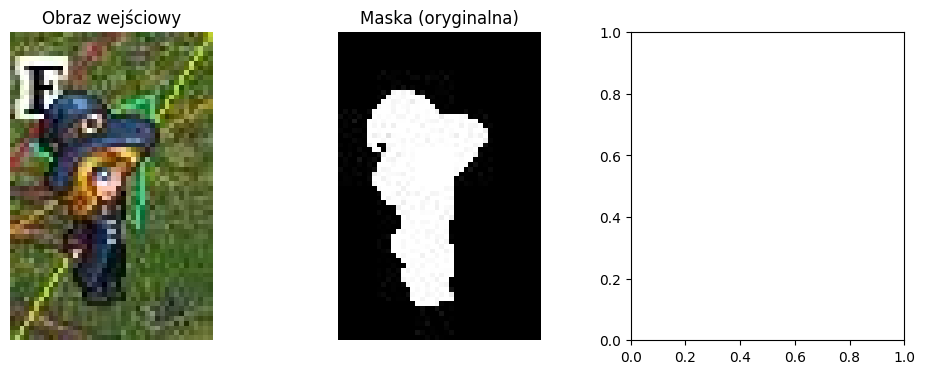

In [6]:
import cv2

img_path = os.path.join(images_dir, train_df.iloc[0]['file'])
mask_path = os.path.join(images_dir, train_df.iloc[0]['mask'])
print(train_df.iloc[0]['file'])
# Otwieranie obrazów przez cv2
image_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
print("Lewy górny piksel obrazu (BGR, oryginalny):", image_bgr[0, 0])
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
print("Lewy górny piksel obrazu (RGB, po konwersji):", image[0, 0])
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)


fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(image)
axs[0].set_title('Obraz wejściowy')
axs[0].axis('off')
axs[1].imshow(mask, cmap='gray')
axs[1].set_title('Maska (oryginalna)')
axs[1].axis('off')
axs[2].imshow(mask_bin, cmap='gray')
axs[2].set_title('Maska (binarna)')
axs[2].axis('off')
plt.tight_layout()
plt.show()

In [7]:

from tensorflow.keras.models import load_model
model_path = os.path.join('model', 'sprite_mask_unet.keras')
model = load_model(model_path)

X_test, y_test = train_dataset[5]
img = X_test[0]
true_mask = y_test[0]

print(img.shape, true_mask.shape)
pred_mask = model.predict(img[np.newaxis, ...])[0]

pred_mask_bin = (pred_mask > 0.5).astype(np.float32)

mask_applied = pred_mask_bin * img

fig, axs = plt.subplots(1, 2, figsize=(16, 4))
axs[0].imshow(img)
axs[0].set_title('Obraz wejściowy')
axs[0].axis('off')
axs[1].imshow(mask_applied.squeeze(), cmap='gray')
axs[1].set_title('Maska prawdziwa')
axs[1].axis('off')
# axs[2].imshow(pred_mask.squeeze(), cmap='gray')
# axs[2].set_title('Maska predykcja (ciągła)')
# axs[2].axis('off')
# axs[3].imshow(pred_mask_bin.squeeze(), cmap='gray')
# axs[3].set_title('Maska predykcja (binarna)')
# axs[3].axis('off')
plt.tight_layout()
plt.show()




ValueError: File not found: filepath=model\sprite_mask_unet.keras. Please ensure the file is an accessible `.keras` zip file.